### Configuration

In [ ]:
# ! pip install timm

2.2.6


### Image Load

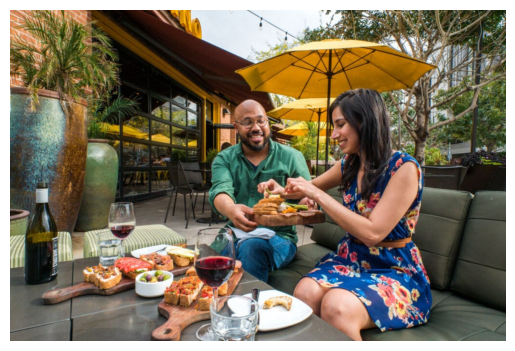

In [8]:
from PIL import Image
import requests

url = "https://azbigmedia.com/wp-content/uploads/2025/07/Postino-Downtown-Tempe-3-1024x684.jpg"
image = Image.open(requests.get(url, stream=True).raw)

import matplotlib.pyplot as plt
plt.imshow(image)
plt.axis("off")
plt.show()

### Image Processing -> Model Loading -> Object Detection

In [9]:
from transformers import DetrImageProcessor, DetrForObjectDetection
import torch

# 1. Load the image processor
processor = DetrImageProcessor.from_pretrained("facebook/detr-resnet-50") 
# 1. Load the model
model = DetrForObjectDetection.from_pretrained("facebook/detr-resnet-50") 

# 2. convert it to a PyTorch tensor
inputs = processor(images=image, return_tensors="pt") 
# 2. forward the processed image through the model
outputs = model(**inputs) 

# 3. Replace (W, H) with (H, W)
target_sizes = torch.tensor([image.size[::-1]]) 
# 3. Filter only results with a probability above the threshold (threshold=0.9).
results = processor.post_process_object_detection(
    outputs, target_sizes=target_sizes, threshold=0.9
    )[0]

Loading weights:   0%|          | 0/530 [00:00<?, ?it/s]

DetrForObjectDetection LOAD REPORT from: facebook/detr-resnet-50
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
model.backbone.model.layer2.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer3.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer1.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer4.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


### Get Detected Object Information

In [10]:
# score is the confidence score, label is the class label and box is the bounding box coordinates
for score, label, box in zip(results["scores"], results["labels"], results["boxes"]): 
    # Round the coordinates of the bounding box to 2 decimal places and convert it to a list.
    box = [round(i, 2) for i in box.tolist()] 
    
    # label.item() gets the integer value of the label
    # model.config.id2label[label.item()] gets class name from the label id
    print(
            f"Detected {model.config.id2label[label.item()]} with confidence "
            f"{round(score.item(), 3)} at location {box}"
    )

Detected wine glass with confidence 0.999 at location [379.14, 449.67, 467.04, 666.53]
Detected umbrella with confidence 0.976 at location [170.99, 225.23, 333.92, 273.68]
Detected potted plant with confidence 0.912 at location [0.22, 1.3, 250.91, 474.72]
Detected couch with confidence 0.928 at location [606.28, 362.21, 1022.41, 679.03]
Detected person with confidence 0.921 at location [434.97, 272.62, 456.52, 291.17]
Detected knife with confidence 0.926 at location [498.0, 572.42, 514.51, 611.56]
Detected bottle with confidence 0.997 at location [32.47, 355.74, 103.07, 570.03]
Detected umbrella with confidence 0.956 at location [464.49, 60.01, 887.37, 308.73]
Detected chair with confidence 0.996 at location [319.24, 316.06, 406.77, 456.34]
Detected cup with confidence 0.986 at location [180.3, 470.39, 230.03, 529.58]
Detected bowl with confidence 0.983 at location [257.21, 539.39, 338.67, 591.18]
Detected person with confidence 1.0 at location [407.57, 184.03, 624.04, 561.44]
Detected

### Visualization

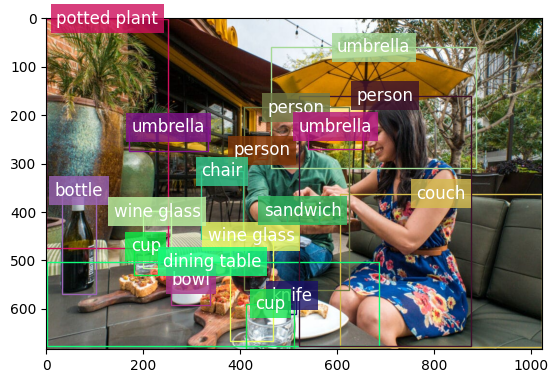

In [11]:
import matplotlib.pyplot as plt
import numpy as np


plt.imshow(image)

for label, box in zip(results["labels"], results["boxes"]):
    box = [round(i, 2) for i in box.tolist()]
    x1, y1, x2, y2 = box
    width = x2 - x1
    height = y1 - y2
    col = (np.random.rand(), np.random.rand(), np.random.rand())            # Generate a random color for the bounding box
    p = plt.Rectangle((x1, y2), width, height, fill=False, edgecolor=col)
    plt.gca().add_patch(p)                                                  # Add the rectangle patch to the current axes
    plt.text((x1+x2)/2, y1, 
             model.config.id2label[label.item()], 
             fontsize=12, color='white', ha='center', va='center',
             bbox=dict(facecolor=col, alpha=0.8, edgecolor='none'))         # Add the class label text at the center of the bounding box

plt.show()